# Sistem Rekomendasi Warna Pakaian Berbasis Ekstraksi Warna Kulit



## 1. Install & Import Library

Cell ini menginstal library tambahan yang dibutuhkan dan mengimpor semua paket utama untuk image processing, clustering, evaluasi warna, dan visualisasi.


In [1]:
!pip install colormath scikit-image -q

import os
import cv2
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from colormath.color_objects import LabColor, sRGBColor
from colormath.color_conversions import convert_color
from colormath.color_diff import delta_e_cie2000

warnings.filterwarnings("ignore")

if not hasattr(np, "asscalar"):
    np.asscalar = lambda x: x.item()

plt.rcParams["figure.dpi"] = 110
print("Library berhasil diimpor")
print("OpenCV:", cv2.__version__)
print("NumPy :", np.__version__)


  Preparing metadata (setup.py) ... done
Library berhasil diimpor
OpenCV: 4.13.0
NumPy : 2.0.2


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Load Dataset

Notebook akan mencoba memuat gambar dari `DATASET_PATH` terlebih dahulu. Jika folder tidak ditemukan atau kosong, notebook otomatis membuat gambar sintetis sebagai fallback agar seluruh pipeline tetap dapat dijalankan untuk demonstrasi.

## Cara Menggunakan Dataset Kaggle

1. Mount Google Drive:
   ```python
   from google.colab import drive
   drive.mount('/content/drive')
   ```
2. Ubah `DATASET_PATH` ke path folder dataset di Drive
3. Dataset yang disarankan:
   - UTKFace (Kaggle) - 20,000+ citra wajah, variasi usia, etnis, gender
   - FairFace (Kaggle) - dirancang untuk keseimbangan ras
   - Dataset wajah multi-etnis lainnya

Spesifikasi minimum dataset untuk penelitian ini:

| Aspek | Minimum |
|---|---|
| Jumlah | minimal 120 citra wajah |
| Variasi | mencakup skintone very light hingga dark |
| Tipe | indoor dan outdoor |
| Format | JPG atau PNG |
| Resolusi | minimal 100x100 piksel, akan di-resize ke 256x256 |


Dataset berhasil dimuat: 120 gambar dari /content/drive/MyDrive/19.skripsi/dataset-wajah


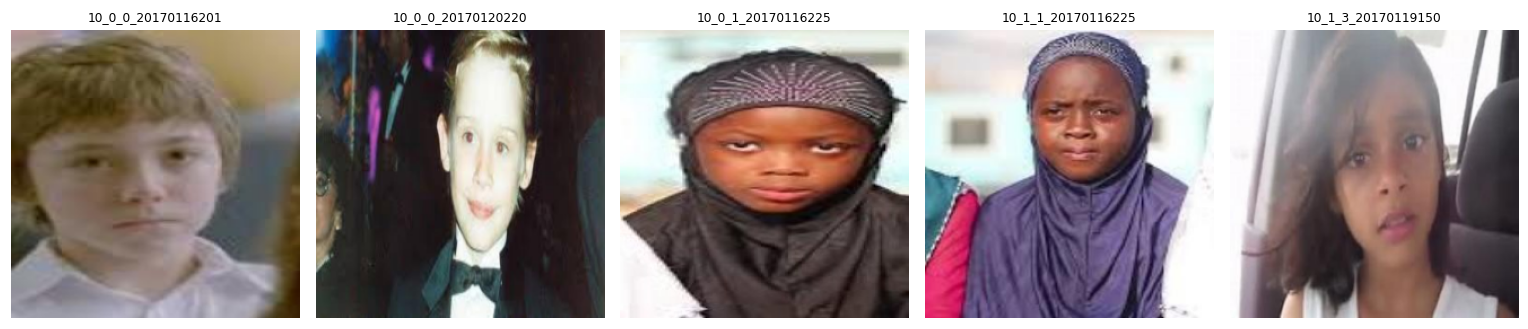

In [3]:
SUPPORTED_EXT = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
TARGET_SIZE = (256, 256)
#DATASET_PATH = "/content/drive/MyDrive/19.skripsi/Dataset_Wajah"
DATASET_PATH = "/content/drive/MyDrive/19.skripsi/dataset-wajah"
SYNTHETIC_COUNT = 36


def generate_synthetic_face(skin_rgb, size=TARGET_SIZE, seed=0):
    rng = np.random.default_rng(seed)
    w, h = size
    img = np.ones((h, w, 3), dtype=np.uint8) * np.array([225, 225, 225], dtype=np.uint8)
    center = (w // 2 + int(rng.integers(-8, 9)), h // 2 + int(rng.integers(-6, 7)))
    axes = (int(w * 0.30), int(h * 0.38))
    cv2.ellipse(img, center, axes, 0, 0, 360, skin_rgb[::-1], -1)
    cv2.circle(img, (center[0] - 28, center[1] - 25), 6, (35, 35, 35), -1)
    cv2.circle(img, (center[0] + 28, center[1] - 25), 6, (35, 35, 35), -1)
    cv2.ellipse(img, (center[0], center[1] + 28), (28, 11), 0, 0, 180, (80, 50, 45), 2)
    noise = rng.normal(0, 7, img.shape)
    return np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)


def make_synthetic_dataset(n=SYNTHETIC_COUNT):
    base_colors = [
        (255, 224, 189), (241, 194, 125), (224, 172, 105),
        (198, 134, 66), (180, 120, 60), (141, 85, 36),
        (110, 65, 30), (70, 35, 15),
    ]
    images = []
    for i in range(n):
        skin_rgb = base_colors[i % len(base_colors)]
        img = generate_synthetic_face(skin_rgb, seed=i)
        images.append((f"synthetic_{i+1:03d}.png", img))
    return images


def load_dataset(folder_path, target_size=TARGET_SIZE):
    images = []
    if os.path.isdir(folder_path):
        for fname in sorted(os.listdir(folder_path)):
            if not fname.lower().endswith(SUPPORTED_EXT):
                continue
            fpath = os.path.join(folder_path, fname)
            img = cv2.imread(fpath)
            if img is None:
                print(f"Gagal membaca file: {fname}")
                continue
            img = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)
            images.append((fname, img))

    if len(images) == 0:
        images = make_synthetic_dataset()
        print(f"PERINGATAN: Dataset tidak ditemukan. {len(images)} gambar sintetis dibuat sebagai fallback.")
        print("Untuk eksperimen nyata, ganti DATASET_PATH dengan dataset Kaggle kamu.")
    else:
        print(f"Dataset berhasil dimuat: {len(images)} gambar dari {folder_path}")
    return images


dataset = load_dataset(DATASET_PATH)

fig, axes = plt.subplots(1, min(5, len(dataset)), figsize=(14, 3))
if len(dataset) == 1:
    axes = [axes]
for ax, (fname, img_bgr) in zip(axes, dataset[:5]):
    ax.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    ax.set_title(fname[:18], fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 3. Preprocessing

Preprocessing menggunakan Gaussian Blur untuk mengurangi noise dan CLAHE pada channel L di CIELAB untuk normalisasi pencahayaan. CLAHE membantu menjaga detail lokal pada wajah sehingga segmentasi kulit tidak terlalu dipengaruhi bayangan atau pencahayaan tidak merata.


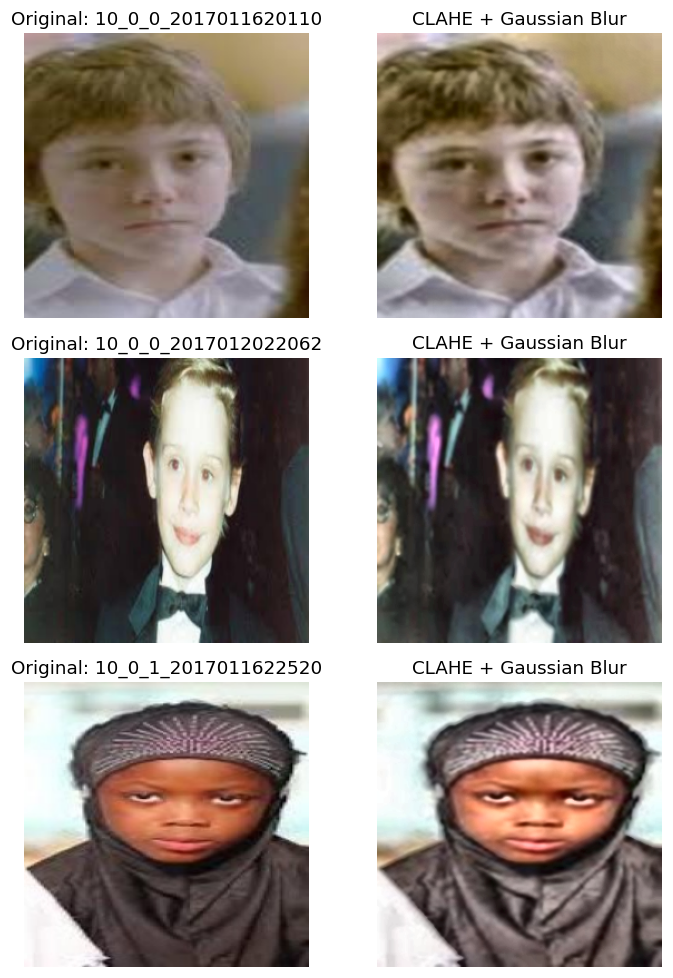

In [4]:
def preprocess_image(img_bgr, apply_blur=True, normalize_lighting=True):
    img = img_bgr.copy()
    if apply_blur:
        img = cv2.GaussianBlur(img, (5, 5), 0)
    if normalize_lighting:
        lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        lab[:, :, 0] = clahe.apply(lab[:, :, 0])
        img = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)
    return img


preprocessed_dataset = [(fname, preprocess_image(img)) for fname, img in dataset]

def visualize_preprocessing(original_dataset, processed_dataset, n=3):
    n = min(n, len(original_dataset))
    fig, axes = plt.subplots(n, 2, figsize=(7, 3 * n))
    if n == 1:
        axes = np.array([axes])
    for i in range(n):
        fname, original = original_dataset[i]
        _, processed = processed_dataset[i]
        axes[i, 0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
        axes[i, 0].set_title(f"Original: {fname[:20]}")
        axes[i, 1].imshow(cv2.cvtColor(processed, cv2.COLOR_BGR2RGB))
        axes[i, 1].set_title("CLAHE + Gaussian Blur")
        for ax in axes[i]:
            ax.axis("off")
    plt.tight_layout()
    plt.show()


visualize_preprocessing(dataset, preprocessed_dataset, n=3)


## 4. Deteksi Wajah - Haar Cascade

Haar Cascade dipilih karena ringan, tidak memerlukan GPU, sudah tersedia di OpenCV tanpa instalasi tambahan, dan cukup untuk citra wajah frontal dengan ekspresi natural sesuai batasan masalah penelitian.

Parameter utama:

| Parameter | Nilai | Fungsi |
|---|---:|---|
| `scaleFactor` | 1.1 | skala pencarian multi-resolusi |
| `minNeighbors` | 5 | mengurangi false positive |
| `minSize` | (60, 60) | mengabaikan deteksi terlalu kecil |
| `padding` | 0.15 | memperluas crop agar pipi dan dahi ikut |

Jika lebih dari satu wajah terdeteksi, sistem mengambil wajah terbesar berdasarkan area. Jika lebih dari 50 persen gambar gagal terdeteksi, dataset preprocessing digunakan langsung sebagai fallback karena dataset sintetis atau non-frontal dapat gagal pada Haar Cascade.


Deteksi wajah berhasil: 97 dari 120 gambar
Gambar di-skip: 23


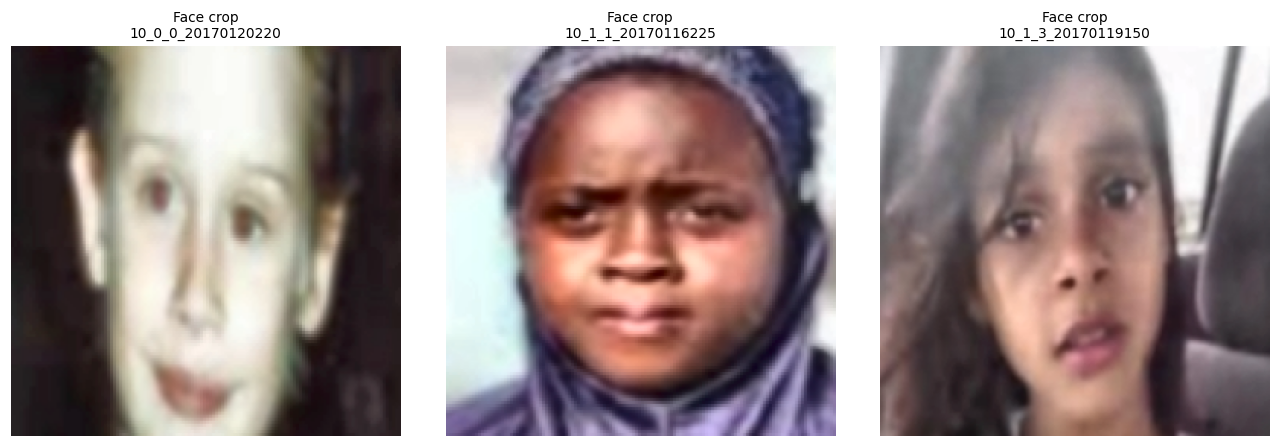

In [5]:
FACE_CASCADE = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")


def detect_and_crop_face(img_bgr, scaleFactor=1.1, minNeighbors=5, minSize=(60, 60), padding=0.15):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    faces = FACE_CASCADE.detectMultiScale(
        gray,
        scaleFactor=scaleFactor,
        minNeighbors=minNeighbors,
        minSize=minSize,
    )
    if len(faces) == 0:
        return None, None

    x, y, w, h = max(faces, key=lambda box: box[2] * box[3])
    pad_x = int(w * padding)
    pad_y = int(h * padding)
    x1 = max(0, x - pad_x)
    y1 = max(0, y - pad_y)
    x2 = min(img_bgr.shape[1], x + w + pad_x)
    y2 = min(img_bgr.shape[0], y + h + pad_y)
    return img_bgr[y1:y2, x1:x2].copy(), (x1, y1, x2 - x1, y2 - y1)


def detect_faces_dataset(preprocessed_dataset):
    detected = []
    skipped = []
    for fname, img_bgr in preprocessed_dataset:
        face_crop, bbox = detect_and_crop_face(img_bgr)
        if face_crop is None:
            skipped.append(fname)
            continue
        face_crop = cv2.resize(face_crop, TARGET_SIZE, interpolation=cv2.INTER_AREA)
        detected.append((fname, face_crop, bbox))

    total = len(preprocessed_dataset)
    print(f"Deteksi wajah berhasil: {len(detected)} dari {total} gambar")
    print(f"Gambar di-skip: {len(skipped)}")

    if total > 0 and len(skipped) / total > 0.50:
        print("Fallback aktif: lebih dari 50% gambar gagal deteksi wajah.")
        return [(fname, img_bgr, None) for fname, img_bgr in preprocessed_dataset], skipped, True
    return detected, skipped, False


face_dataset, skipped_faces, face_detection_fallback = detect_faces_dataset(preprocessed_dataset)

def visualize_face_crops(dataset_with_faces, n=3):
    n = min(n, len(dataset_with_faces))
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, (fname, img_bgr, bbox) in zip(axes, dataset_with_faces[:n]):
        ax.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
        title = "Fallback crop" if bbox is None else "Face crop"
        ax.set_title(f"{title}\n{fname[:18]}", fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


visualize_face_crops(face_dataset, n=3)


## 5. Segmentasi Kulit - Voting 3 Color Space

Segmentasi kulit menggunakan voting dari RGB, HSV, dan YCrCb. Pixel dianggap kulit jika lolos minimal dua dari tiga threshold. K-Means hanya diterapkan pada pixel kulit yang telah lolos segmentasi, bukan seluruh pixel gambar.

Threshold ringkas:

| Color Space | Aturan |
|---|---|
| RGB | R > 95, G > 40, B > 20, R > G, R > B, abs(R-G) > 15 |
| HSV | H area merah-kulit, S moderat, V cukup terang |
| YCrCb | Cr 133-173 dan Cb 77-127 |


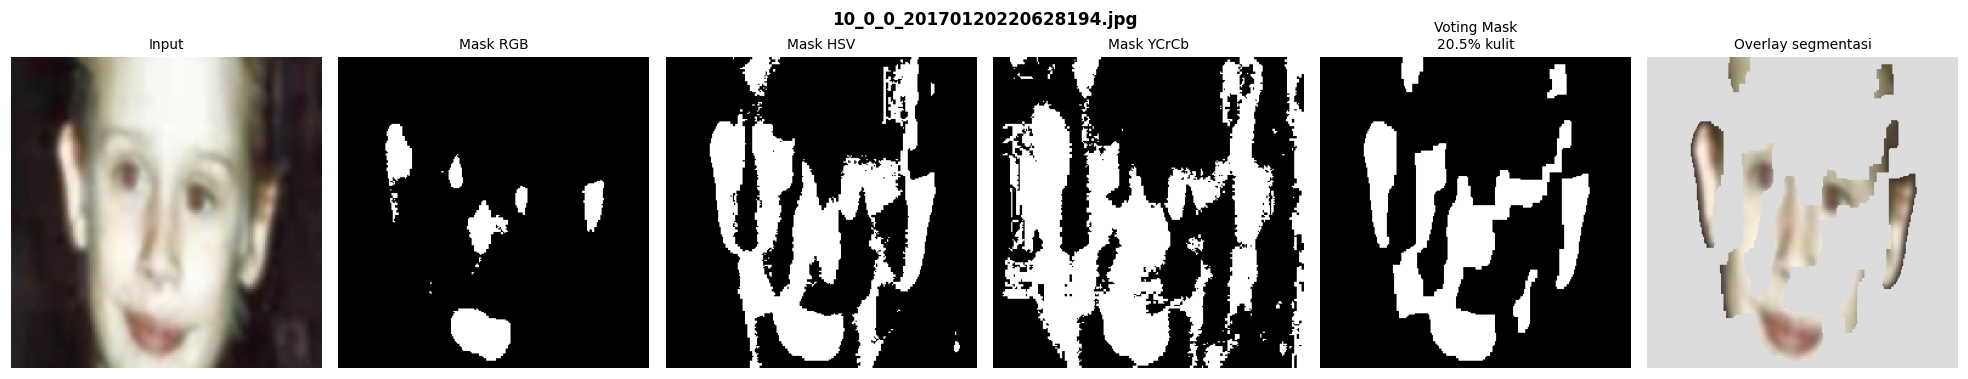

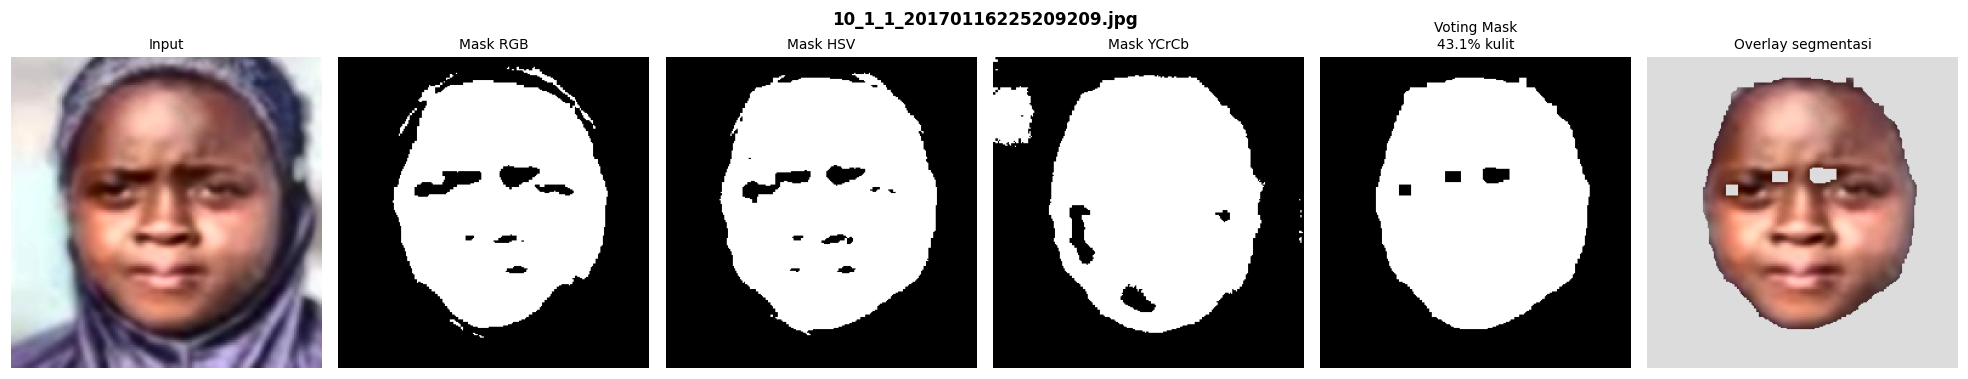

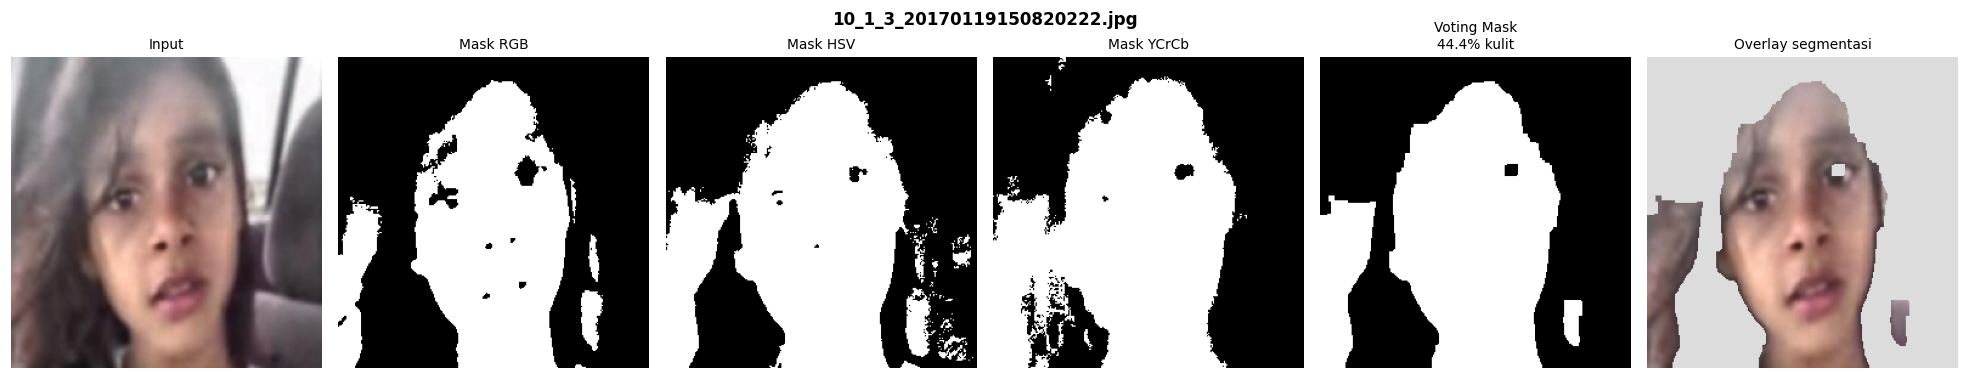

In [6]:
def segment_skin_rgb(img_bgr):
    img = img_bgr.astype(np.float32)
    b, g, r = img[:, :, 0], img[:, :, 1], img[:, :, 2]
    mask = (
        (r > 95) & (g > 40) & (b > 20) &
        (r > g) & (r > b) &
        (np.abs(r - g) > 15) &
        ((np.max(img, axis=2) - np.min(img, axis=2)) > 15)
    )
    return (mask.astype(np.uint8) * 255)


def segment_skin_hsv(img_bgr):
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    lower = cv2.inRange(hsv, (0, 25, 70), (25, 180, 255))
    upper = cv2.inRange(hsv, (160, 25, 70), (179, 180, 255))
    return cv2.bitwise_or(lower, upper)


def segment_skin_ycrcb(img_bgr):
    ycrcb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2YCrCb)
    return cv2.inRange(ycrcb, (0, 133, 77), (255, 173, 127))


def clean_mask(mask):
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    return mask


def segment_skin_combined(img_bgr):
    mask_rgb = segment_skin_rgb(img_bgr)
    mask_hsv = segment_skin_hsv(img_bgr)
    mask_ycrcb = segment_skin_ycrcb(img_bgr)
    votes = (mask_rgb > 0).astype(np.uint8) + (mask_hsv > 0).astype(np.uint8) + (mask_ycrcb > 0).astype(np.uint8)
    combined = clean_mask((votes >= 2).astype(np.uint8) * 255)
    return combined, {"RGB": mask_rgb, "HSV": mask_hsv, "YCrCb": mask_ycrcb}


def visualize_segmentation(img_bgr, fname=""):
    mask, masks = segment_skin_combined(img_bgr)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    overlay = img_rgb.copy()
    overlay[mask == 0] = [220, 220, 220]
    pct = (mask > 0).mean() * 100

    fig, axes = plt.subplots(1, 6, figsize=(18, 3.5))
    panels = [
        (img_rgb, "Input", None),
        (masks["RGB"], "Mask RGB", "gray"),
        (masks["HSV"], "Mask HSV", "gray"),
        (masks["YCrCb"], "Mask YCrCb", "gray"),
        (mask, f"Voting Mask\n{pct:.1f}% kulit", "gray"),
        (overlay, "Overlay segmentasi", None),
    ]
    for ax, (im, title, cmap) in zip(axes, panels):
        ax.imshow(im, cmap=cmap)
        ax.set_title(title, fontsize=9)
        ax.axis("off")
    fig.suptitle(fname, fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.show()


for fname, img_bgr, _ in face_dataset[:3]:
    visualize_segmentation(img_bgr, fname)


## 6. Ekstraksi Pixel Kulit

Pixel kulit diekstrak dari mask segmentasi gabungan, lalu dikonversi ke color space yang dianalisis: RGB, HSV, dan LAB. Distribusi pixel divisualisasikan untuk memeriksa sebaran warna sebelum clustering.


Jumlah pixel kulit:
RGB: 3363613 | HSV: 3363613 | LAB: 3363613


,filename,skin_pixels,skin_pct
0,10_0_0_20170120220628194.jpg,13452,20.526123
1,10_1_1_20170116225209209.jpg,28275,43.144226
2,10_1_3_20170119150820222.jpg,29071,44.358826
3,11_1_0_20170117133441179.jpg,0,0.000000
4,13_0_3_20170119153840721.jpg,29390,44.845581


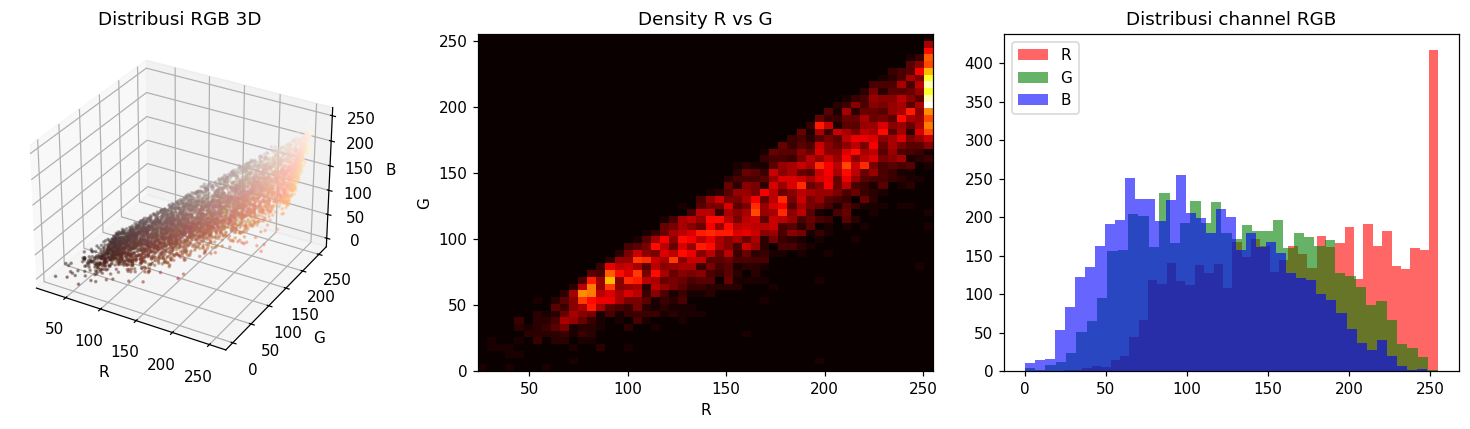

In [7]:
def extract_skin_pixels(img_bgr, color_space="RGB", min_pixels=50):
    mask, _ = segment_skin_combined(img_bgr)
    if color_space == "RGB":
        img_cs = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    elif color_space == "HSV":
        img_cs = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    elif color_space == "LAB":
        img_cs = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    else:
        raise ValueError("color_space harus RGB, HSV, atau LAB")

    pixels = img_cs[mask > 0].reshape(-1, 3).astype(np.float32)
    if len(pixels) < min_pixels:
        return None, mask
    return pixels, mask


def collect_all_skin_pixels(dataset_with_faces, color_space="RGB"):
    all_pixels = []
    summary = []
    for fname, img_bgr, _ in dataset_with_faces:
        pixels, mask = extract_skin_pixels(img_bgr, color_space=color_space)
        count = 0 if pixels is None else len(pixels)
        summary.append({"filename": fname, "skin_pixels": count, "skin_pct": (mask > 0).mean() * 100})
        if pixels is not None:
            all_pixels.append(pixels)
    if not all_pixels:
        raise RuntimeError(f"Tidak ada pixel kulit valid untuk color space {color_space}")
    return np.vstack(all_pixels), pd.DataFrame(summary)


pixels_rgb, summary_rgb = collect_all_skin_pixels(face_dataset, "RGB")
pixels_hsv, summary_hsv = collect_all_skin_pixels(face_dataset, "HSV")
pixels_lab, summary_lab = collect_all_skin_pixels(face_dataset, "LAB")

print("Jumlah pixel kulit:")
print("RGB:", len(pixels_rgb), "| HSV:", len(pixels_hsv), "| LAB:", len(pixels_lab))
display(summary_rgb.head())


def plot_pixel_distribution(pixels_rgb, n_sample=5000):
    sample = pixels_rgb
    if len(sample) > n_sample:
        idx = np.random.default_rng(42).choice(len(sample), n_sample, replace=False)
        sample = sample[idx]
    colors = np.clip(sample / 255.0, 0, 1)

    fig = plt.figure(figsize=(14, 4))
    ax1 = fig.add_subplot(131, projection="3d")
    ax1.scatter(sample[:, 0], sample[:, 1], sample[:, 2], c=colors, s=2, alpha=0.35)
    ax1.set_xlabel("R"); ax1.set_ylabel("G"); ax1.set_zlabel("B")
    ax1.set_title("Distribusi RGB 3D")

    ax2 = fig.add_subplot(132)
    ax2.hist2d(sample[:, 0], sample[:, 1], bins=50, cmap="hot")
    ax2.set_xlabel("R"); ax2.set_ylabel("G")
    ax2.set_title("Density R vs G")

    ax3 = fig.add_subplot(133)
    ax3.hist(sample[:, 0], bins=40, alpha=0.6, color="red", label="R")
    ax3.hist(sample[:, 1], bins=40, alpha=0.6, color="green", label="G")
    ax3.hist(sample[:, 2], bins=40, alpha=0.6, color="blue", label="B")
    ax3.set_title("Distribusi channel RGB")
    ax3.legend()
    plt.tight_layout()
    plt.show()


plot_pixel_distribution(pixels_rgb)


## 7. Elbow Method + K-Means Clustering

Elbow Method digunakan untuk melihat perubahan inertia pada beberapa nilai K. Penelitian ini tetap membandingkan K kandidat `[3, 5, 7]` agar evaluasi antar color space konsisten. Jika elbow menghasilkan nilai lain, nilai tersebut tetap dicatat sebagai referensi, namun pemilihan akhir menggunakan composite score pada konfigurasi yang diuji.


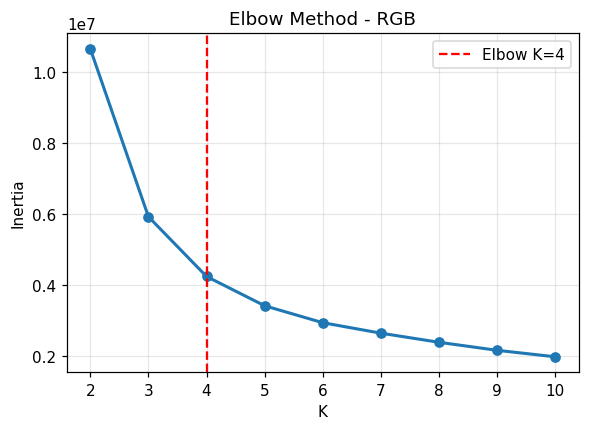

RGB | K=3 | Inertia=7406524.00
RGB | K=5 | Inertia=4254135.50
RGB | K=7 | Inertia=3281391.75
HSV | K=3 | Inertia=12162169.00
HSV | K=5 | Inertia=7470458.00
HSV | K=7 | Inertia=5620293.00
LAB | K=3 | Inertia=2514213.25
LAB | K=5 | Inertia=1447773.50
LAB | K=7 | Inertia=1120766.38


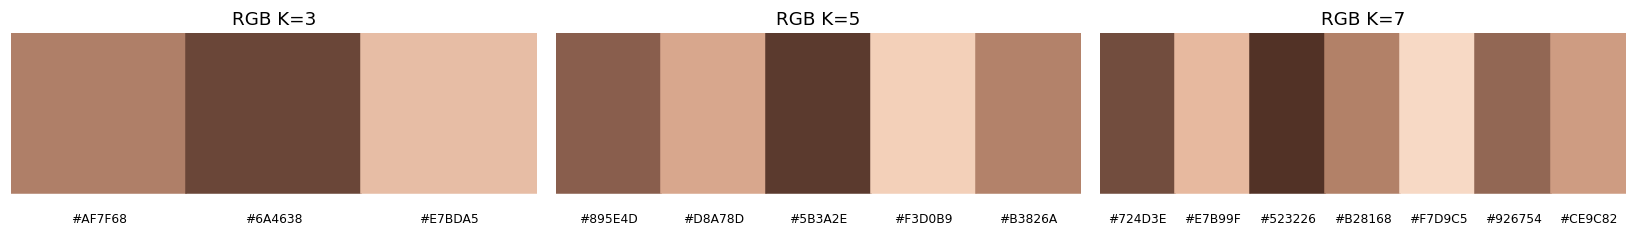

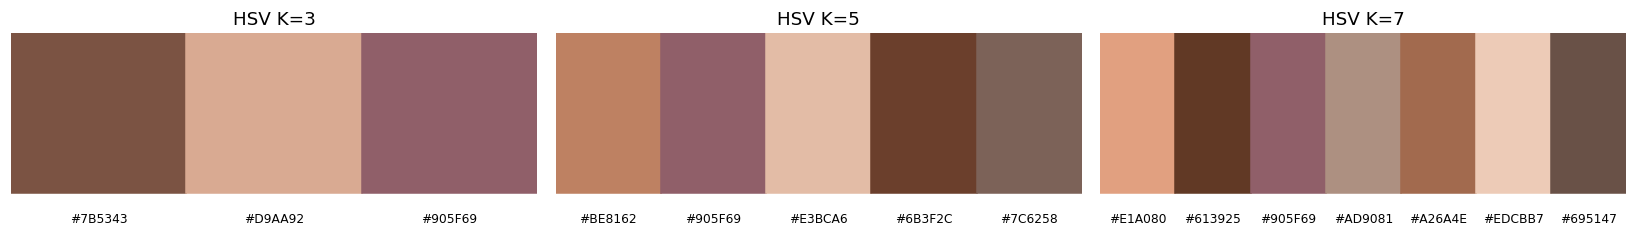

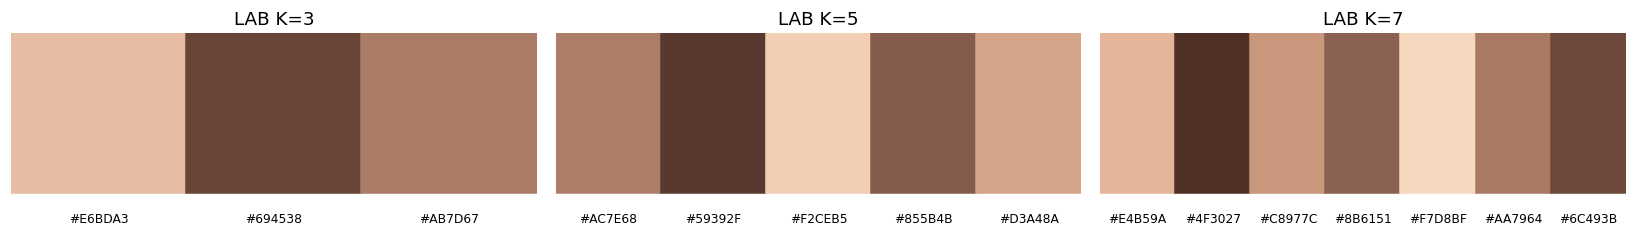

In [8]:
K_VALUES = [3, 5, 7]
N_SAMPLE_FIT = 5000


def sample_pixels(pixels, n=N_SAMPLE_FIT, seed=42):
    if len(pixels) > n:
        idx = np.random.default_rng(seed).choice(len(pixels), n, replace=False)
        return pixels[idx]
    return pixels


def run_kmeans(pixels, k, random_state=42):
    k = int(min(k, len(pixels)))
    model = KMeans(n_clusters=k, init="k-means++", n_init=10, max_iter=300, random_state=random_state)
    labels = model.fit_predict(pixels)
    return model, labels, model.cluster_centers_, model.inertia_


def elbow_method(pixels, k_range=range(2, 11), color_space="RGB", n_sample=4000):
    sample = sample_pixels(pixels, n_sample)
    inertias = []
    valid_k = []
    for k in k_range:
        if k >= len(sample):
            continue
        _, _, _, inertia = run_kmeans(sample, k)
        valid_k.append(k)
        inertias.append(inertia)

    if len(inertias) >= 3:
        diffs = np.diff(inertias)
        second = np.diff(diffs)
        best_k = valid_k[int(np.argmax(second)) + 2]
    else:
        best_k = valid_k[0]

    plt.figure(figsize=(6, 4))
    plt.plot(valid_k, inertias, "o-", linewidth=2)
    plt.axvline(best_k, color="red", linestyle="--", label=f"Elbow K={best_k}")
    plt.title(f"Elbow Method - {color_space}")
    plt.xlabel("K")
    plt.ylabel("Inertia")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()
    return best_k, pd.DataFrame({"K": valid_k, "Inertia": inertias})


def fit_kmeans_multiple_k(pixels, k_values, color_space="RGB"):
    sample = sample_pixels(pixels)
    results = {}
    for k in k_values:
        model, labels, centroids, inertia = run_kmeans(sample, k)
        results[k] = {
            "model": model,
            "labels": labels,
            "centroids": centroids,
            "inertia": inertia,
            "pixels": sample,
        }
        print(f"{color_space} | K={k} | Inertia={inertia:.2f}")
    return results


best_k_rgb_elbow, elbow_rgb = elbow_method(pixels_rgb, color_space="RGB")
results_rgb = fit_kmeans_multiple_k(pixels_rgb, K_VALUES, "RGB")
results_hsv = fit_kmeans_multiple_k(pixels_hsv, K_VALUES, "HSV")
results_lab = fit_kmeans_multiple_k(pixels_lab, K_VALUES, "LAB")


def centroids_rgb_from_space(centroids, color_space):
    centroids = np.clip(centroids, 0, 255).astype(np.uint8)
    if color_space == "RGB":
        return centroids
    converted = []
    code_map = {"HSV": cv2.COLOR_HSV2RGB, "LAB": cv2.COLOR_LAB2RGB}
    for c in centroids:
        px = np.uint8([[c]])
        converted.append(cv2.cvtColor(px, code_map[color_space])[0, 0])
    return np.array(converted, dtype=np.uint8)


def plot_centroids(results, color_space="RGB"):
    fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 2.4))
    if len(results) == 1:
        axes = [axes]
    for ax, (k, res) in zip(axes, results.items()):
        centroids_rgb = centroids_rgb_from_space(res["centroids"], color_space)
        for i, rgb in enumerate(centroids_rgb):
            ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=rgb / 255.0))
            ax.text(i + 0.5, -0.12, "#{:02X}{:02X}{:02X}".format(*rgb), ha="center", va="top", fontsize=8)
        ax.set_xlim(0, len(centroids_rgb))
        ax.set_ylim(-0.3, 1)
        ax.set_title(f"{color_space} K={k}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()


plot_centroids(results_rgb, "RGB")
plot_centroids(results_hsv, "HSV")
plot_centroids(results_lab, "LAB")


## 8. Evaluasi Clustering

Metrik evaluasi digunakan untuk membaca struktur cluster, bukan untuk membuktikan bahwa centroid pasti merupakan warna kulit yang benar secara visual.

| Metrik | Arah terbaik | Keterangan |
|---|:---:|---|
| Silhouette Score | naik | separasi dan kepadatan cluster |
| Davies-Bouldin Index | turun | rata-rata kemiripan antar cluster |
| Calinski-Harabasz Index | naik | rasio dispersi antar dan intra cluster |

PERINGATAN: metrik clustering tidak sama dengan bukti kebenaran warna kulit. Validasi visual-perseptual dilakukan terpisah dengan CIEDE2000 pada Section 12.


,Color Space,K,silhouette,davies_bouldin,calinski_harabasz
0,RGB,3,0.4784,0.6783,6951.57
1,RGB,5,0.3759,0.8436,6547.56
2,RGB,7,0.3100,1.0033,5775.46
3,HSV,3,0.4461,0.7986,2589.12
4,HSV,5,0.3774,0.8460,2602.26
5,HSV,7,0.3631,0.7928,2502.81
6,LAB,3,0.4769,0.6770,6972.03
7,LAB,5,0.3707,0.8494,6535.20
8,LAB,7,0.3085,1.0035,5768.30


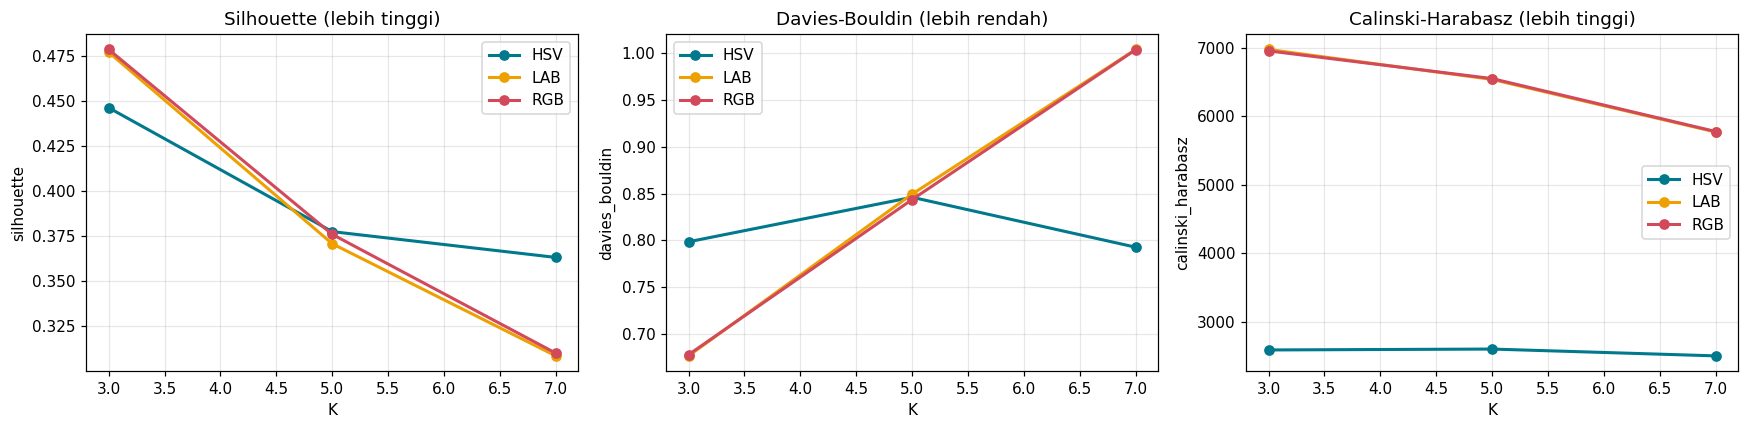

In [9]:
def evaluate_clustering(pixels, labels, name=""):
    unique = np.unique(labels)
    if len(unique) < 2:
        return {"silhouette": 0, "davies_bouldin": 999, "calinski_harabasz": 0}
    if len(pixels) > 3000:
        idx = np.random.default_rng(42).choice(len(pixels), 3000, replace=False)
        px = pixels[idx]
        lb = labels[idx]
    else:
        px = pixels
        lb = labels
    return {
        "silhouette": round(float(silhouette_score(px, lb)), 4),
        "davies_bouldin": round(float(davies_bouldin_score(px, lb)), 4),
        "calinski_harabasz": round(float(calinski_harabasz_score(px, lb)), 2),
    }


def evaluate_all(results_dict, color_space):
    rows = []
    for k, res in results_dict.items():
        metrics = evaluate_clustering(res["pixels"], res["labels"])
        rows.append({"Color Space": color_space, "K": k, **metrics})
    return pd.DataFrame(rows)


df_eval = pd.concat([
    evaluate_all(results_rgb, "RGB"),
    evaluate_all(results_hsv, "HSV"),
    evaluate_all(results_lab, "LAB"),
], ignore_index=True)
display(df_eval)


def plot_evaluation_comparison(df_eval):
    metrics = ["silhouette", "davies_bouldin", "calinski_harabasz"]
    titles = ["Silhouette (lebih tinggi)", "Davies-Bouldin (lebih rendah)", "Calinski-Harabasz (lebih tinggi)"]
    colors = {"RGB": "#D1495B", "HSV": "#00798C", "LAB": "#EDA000"}
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    for ax, metric, title in zip(axes, metrics, titles):
        for cs, grp in df_eval.groupby("Color Space"):
            ax.plot(grp["K"], grp[metric], "o-", label=cs, color=colors[cs], linewidth=2)
        ax.set_title(title)
        ax.set_xlabel("K")
        ax.set_ylabel(metric)
        ax.grid(alpha=0.3)
        ax.legend()
    plt.tight_layout()
    plt.show()


plot_evaluation_comparison(df_eval)


## 9. Analisis Stabilitas + Pemilihan Model Terbaik

Stabilitas dihitung dari variasi centroid saat K-Means dijalankan beberapa kali dengan seed berbeda. Composite score menggabungkan:

`0.35 * Silhouette + 0.25 * inverse(DBI) + 0.20 * CHI + 0.20 * inverse(Stability)`

Skor tertinggi dipilih sebagai konfigurasi terbaik.


,Color Space,K,Stability Score
0,RGB,3,0.153311
1,RGB,5,0.433265
2,RGB,7,0.589135
3,HSV,3,0.000000
4,HSV,5,0.000000
5,HSV,7,2.449158
6,LAB,3,0.459932
7,LAB,5,0.506667
8,LAB,7,0.127128


,Color Space,K,silhouette,davies_bouldin,calinski_harabasz,Stability Score,score_sil,score_db,score_ch,score_stab,composite
0,RGB,3,0.4784,0.6783,6951.57,0.153311,1.000000,9.960184e-01,0.995422,9.374027e-01,0.985570
1,LAB,3,0.4769,0.6770,6972.03,0.459932,0.991171,1.000000e+00,1.000000,8.122081e-01,0.959352
2,HSV,3,0.4461,0.7986,2589.12,0.000000,0.809888,6.275651e-01,0.019312,1.000000e+00,0.644215
3,RGB,5,0.3759,0.8436,6547.56,0.433265,0.396704,4.897397e-01,0.905024,8.230962e-01,0.606905
4,LAB,5,0.3707,0.8494,6535.20,0.506667,0.366098,4.719755e-01,0.902258,7.931261e-01,0.585205
5,HSV,5,0.3774,0.8460,2602.26,0.000000,0.405533,4.823890e-01,0.022252,1.000000e+00,0.466984
6,LAB,7,0.3085,1.0035,5768.30,0.127128,0.000000,3.062787e-09,0.730662,9.480931e-01,0.335751
7,RGB,7,0.3100,1.0033,5775.46,0.589135,0.008829,6.125605e-04,0.732264,7.594539e-01,0.301587
8,HSV,7,0.3631,0.7928,2502.81,2.449158,0.321366,6.453293e-01,0.000000,4.083037e-10,0.273810


Model terbaik: RGB, K=3, composite=0.9856


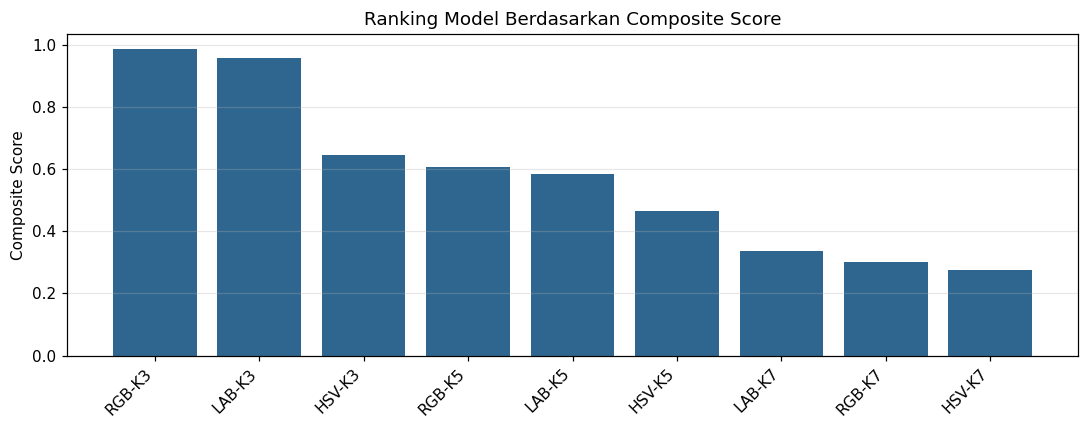

In [10]:
def compute_cluster_stability(pixels, k, n_runs=5, color_space="RGB"):
    sample = sample_pixels(pixels, n=3000)
    all_centroids = []
    for seed in range(n_runs):
        _, _, centroids, _ = run_kmeans(sample, k, random_state=seed * 11 + 7)
        centroids_rgb = centroids_rgb_from_space(centroids, color_space).astype(np.float32)
        order = np.argsort(centroids_rgb.mean(axis=1))
        all_centroids.append(centroids_rgb[order])
    return float(np.array(all_centroids).std(axis=0).mean())


stability_rows = []
for cs, px in [("RGB", pixels_rgb), ("HSV", pixels_hsv), ("LAB", pixels_lab)]:
    for k in K_VALUES:
        stability_rows.append({
            "Color Space": cs,
            "K": k,
            "Stability Score": compute_cluster_stability(px, k, color_space=cs),
        })
df_stability = pd.DataFrame(stability_rows)
display(df_stability)


def select_best_model(df_eval, df_stability):
    df = df_eval.merge(df_stability, on=["Color Space", "K"])
    def norm_up(s):
        return (s - s.min()) / (s.max() - s.min() + 1e-9)
    def norm_down(s):
        return 1 - norm_up(s)

    df["score_sil"] = norm_up(df["silhouette"])
    df["score_db"] = norm_down(df["davies_bouldin"])
    df["score_ch"] = norm_up(df["calinski_harabasz"])
    df["score_stab"] = norm_down(df["Stability Score"])
    df["composite"] = (
        0.35 * df["score_sil"] +
        0.25 * df["score_db"] +
        0.20 * df["score_ch"] +
        0.20 * df["score_stab"]
    )
    return df.sort_values("composite", ascending=False).reset_index(drop=True)


df_ranked = select_best_model(df_eval, df_stability)
best_row = df_ranked.iloc[0]
best_cs = str(best_row["Color Space"])
best_k = int(best_row["K"])
BEST_RESULTS_MAP = {"RGB": results_rgb, "HSV": results_hsv, "LAB": results_lab}
best_model_results = BEST_RESULTS_MAP[best_cs]
best_centroids_raw = best_model_results[best_k]["centroids"]
best_centroids_rgb = centroids_rgb_from_space(best_centroids_raw, best_cs)

display(df_ranked)
print(f"Model terbaik: {best_cs}, K={best_k}, composite={best_row['composite']:.4f}")

plt.figure(figsize=(10, 4))
labels = [f"{r['Color Space']}-K{int(r['K'])}" for _, r in df_ranked.iterrows()]
plt.bar(labels, df_ranked["composite"], color="#2F6690")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Composite Score")
plt.title("Ranking Model Berdasarkan Composite Score")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## 10. Klasifikasi Skintone - ITA (CIELAB)

ITA (Individual Typology Angle) adalah standar industri kosmetik dan dermatologi. ITA dihitung dari L* (kecerahan) dan b* (yellow-blue) di CIELAB. Metode ini lebih presisi dari HSV brightness karena memperhitungkan komponen undertone b*, bukan hanya kecerahan.

Kategori ITA:

| Kategori | Rentang ITA |
|---|---:|
| Very Light | ITA > 55 |
| Light | 41 < ITA <= 55 |
| Intermediate | 28 < ITA <= 41 |
| Tan | 10 < ITA <= 28 |
| Brown | -30 < ITA <= 10 |
| Dark | ITA <= -30 |


In [11]:
def rgb_to_cielab_std(rgb_tuple):
    rgb = np.uint8([[list(map(int, rgb_tuple))]])
    lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)[0, 0]
    L_star = (float(lab[0]) / 255.0) * 100.0
    a_star = float(lab[1]) - 128.0
    b_star = float(lab[2]) - 128.0
    return L_star, a_star, b_star


def compute_ita(L_star, b_star):
    if b_star == 0:
        b_star = 1e-6
    return math.degrees(math.atan((L_star - 50.0) / b_star))


def classify_skintone_ita(rgb_tuple):
    L_star, a_star, b_star = rgb_to_cielab_std(rgb_tuple)
    ita_value = compute_ita(L_star, b_star)
    if ita_value > 55:
        category = "Very Light"
    elif ita_value > 41:
        category = "Light"
    elif ita_value > 28:
        category = "Intermediate"
    elif ita_value > 10:
        category = "Tan"
    elif ita_value > -30:
        category = "Brown"
    else:
        category = "Dark"
    return category, float(ita_value), float(L_star), float(b_star)


def classify_undertone_lab(rgb_tuple):
    _, a_star, b_star = rgb_to_cielab_std(rgb_tuple)
    if b_star > 5 and a_star < 10:
        return "Warm"
    if b_star < -2 or a_star > 12:
        return "Cool"
    return "Neutral"


demo_refs = [(255, 224, 189), (210, 160, 90), (70, 35, 15)]
rows = []
for rgb in demo_refs:
    cat, ita, L, b = classify_skintone_ita(rgb)
    rows.append({
        "RGB": rgb,
        "Hex": "#{:02X}{:02X}{:02X}".format(*rgb),
        "Skintone ITA": cat,
        "ITA": round(ita, 2),
        "L*": round(L, 2),
        "b*": round(b, 2),
        "Undertone": classify_undertone_lab(rgb),
    })
display(pd.DataFrame(rows))


,RGB,Hex,Skintone ITA,ITA,L*,b*,Undertone
0,"(255, 224, 189)",#FFE0BD,Very Light,62.87,90.98,21.0,Warm
1,"(210, 160, 90)",#D2A05A,Tan,23.86,69.02,43.0,Neutral
2,"(70, 35, 15)",#46230F,Dark,-57.96,18.04,20.0,Cool


## 11. Engine Rekomendasi Warna Pakaian

Engine rekomendasi menggunakan tabel rule-based berdasarkan kategori ITA dan undertone LAB. Sistem ini tidak menggunakan riwayat pengguna; rekomendasi dihasilkan dari aturan warna yang eksplisit agar metodologi mudah dijelaskan dan direplikasi.


Model terbaik: RGB, K=3
Cluster 1: #AF7F68 | Tan | Cool | ITA=19.94


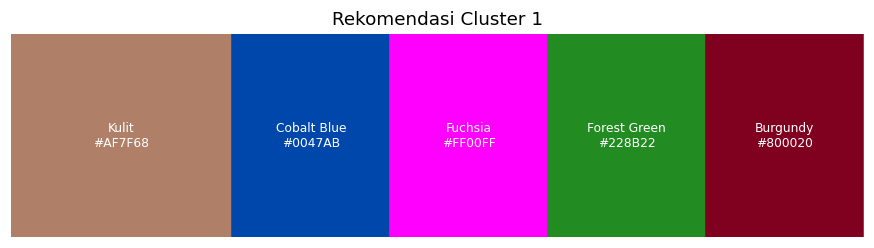

Cluster 2: #6A4638 | Dark | Cool | ITA=-48.01


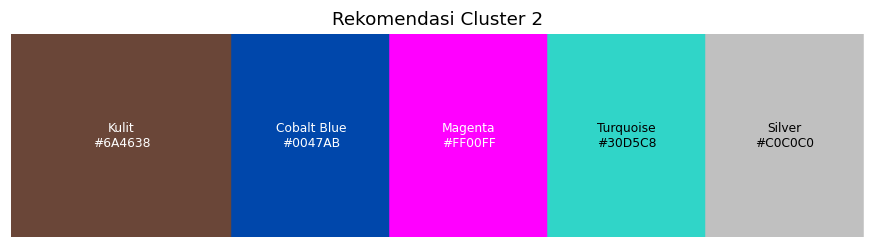

Cluster 3: #E7BDA5 | Very Light | Neutral | ITA=58.70


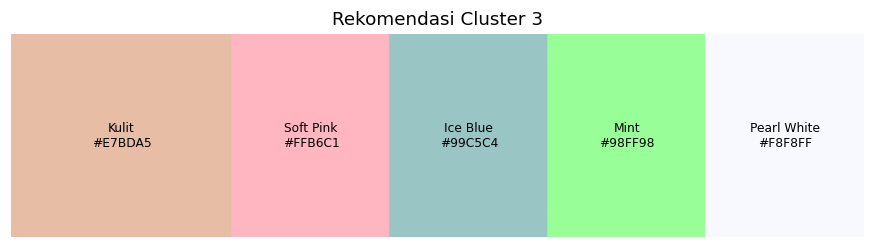

In [12]:
RECOMMENDATION_TABLE = {
    "Very Light": {
        "undertone_map": {
            "Cool": ["Royal Blue", "Emerald", "Lavender", "Silver"],
            "Neutral": ["Soft Pink", "Ice Blue", "Mint", "Pearl White"],
            "Warm": ["Blush Pink", "Peach", "Champagne", "Warm Ivory"],
        },
        "avoid": "Warna sangat pucat (putih murni, cream sangat terang) yang membuat tampilan kusam",
        "harmony": "Complementary",
        "reason": "Kulit sangat terang memerlukan warna jewel tone untuk menciptakan kontras visual yang sehat",
    },
    "Light": {
        "undertone_map": {
            "Cool": ["Dusty Pink", "Periwinkle", "Soft Lavender", "Slate Blue"],
            "Neutral": ["Jade Green", "Off-White", "Taupe", "Grey"],
            "Warm": ["Warm Peach", "Coral", "Dusty Rose", "Sand"],
        },
        "avoid": "Warna neon terlalu terang dan orange yang terlalu jenuh",
        "harmony": "Analogous",
        "reason": "Skintone light cocok dengan warna berdekatan (analogous) untuk tampilan harmonis",
    },
    "Intermediate": {
        "undertone_map": {
            "Cool": ["Mauve", "Dusty Purple", "Teal", "Charcoal"],
            "Neutral": ["Olive Green", "Khaki", "Caramel", "Rust"],
            "Warm": ["Mustard", "Terracotta", "Coral", "Burnt Orange"],
        },
        "avoid": "Warna neon dan kuning-hijau yang terlalu terang",
        "harmony": "Triadic",
        "reason": "Earth tones dan warna hangat melengkapi undertone medium dengan baik",
    },
    "Tan": {
        "undertone_map": {
            "Cool": ["Cobalt Blue", "Fuchsia", "Forest Green", "Burgundy"],
            "Neutral": ["Warm Brown", "Copper", "Amber", "Olive"],
            "Warm": ["Golden Yellow", "Deep Orange", "Saffron", "Rust"],
        },
        "avoid": "Warna coklat muda yang terlalu mirip warna kulit sehingga kontras hilang",
        "harmony": "Monochromatic",
        "reason": "Warna hangat dan cerah menonjolkan kehangatan skintone tan secara alami",
    },
    "Brown": {
        "undertone_map": {
            "Cool": ["Cream", "Lilac", "Soft Turquoise", "Powder Blue"],
            "Neutral": ["Beige", "Ivory", "Forest Green", "Burgundy"],
            "Warm": ["Orange", "Bright Yellow", "Warm Red", "Royal Blue"],
        },
        "avoid": "Warna coklat gelap yang menyatu dengan warna kulit",
        "harmony": "Analogous",
        "reason": "Warna cerah dan terang menciptakan kontras yang menonjolkan skintone brown",
    },
    "Dark": {
        "undertone_map": {
            "Cool": ["Cobalt Blue", "Magenta", "Turquoise", "Silver"],
            "Neutral": ["Maroon", "Forest Green", "Warm White", "Emerald"],
            "Warm": ["Bright Red", "Lime Green", "Hot Pink", "Electric Blue"],
        },
        "avoid": "Warna gelap (hitam, navy gelap, coklat tua) yang mengurangi visibilitas warna kulit",
        "harmony": "Complementary",
        "reason": "Warna vivid dan cerah memberikan kontras kuat yang menonjolkan keindahan skintone dark",
    },
}

COLOR_HEX_REFERENCE = {
    "Royal Blue":"#4169E1", "Emerald":"#50C878", "Lavender":"#E6E6FA", "Silver":"#C0C0C0",
    "Soft Pink":"#FFB6C1", "Ice Blue":"#99C5C4", "Mint":"#98FF98", "Pearl White":"#F8F8FF",
    "Blush Pink":"#FF6B8A", "Peach":"#FFCBA4", "Champagne":"#F7E7CE", "Warm Ivory":"#FFFFF0",
    "Dusty Pink":"#DCAE96", "Periwinkle":"#CCCCFF", "Soft Lavender":"#DCD0FF",
    "Slate Blue":"#6A5ACD", "Jade Green":"#00A86B", "Off-White":"#FAF9F6",
    "Taupe":"#483C32", "Grey":"#808080", "Warm Peach":"#FFCBA4", "Coral":"#FF7F50",
    "Dusty Rose":"#DCAE96", "Sand":"#C2B280", "Mauve":"#E0B0FF", "Dusty Purple":"#B57EDC",
    "Teal":"#008080", "Charcoal":"#36454F", "Olive Green":"#808000", "Khaki":"#C3B091",
    "Caramel":"#C68642", "Rust":"#B7410E", "Mustard":"#FFDB58", "Terracotta":"#E2725B",
    "Burnt Orange":"#CC5500", "Cobalt Blue":"#0047AB", "Fuchsia":"#FF00FF",
    "Forest Green":"#228B22", "Burgundy":"#800020", "Warm Brown":"#964B00",
    "Copper":"#B87333", "Amber":"#FFBF00", "Olive":"#808000", "Golden Yellow":"#FFDF00",
    "Deep Orange":"#FF4500", "Saffron":"#F4C430", "Cream":"#FFFDD0", "Lilac":"#C8A2C8",
    "Soft Turquoise":"#40E0D0", "Powder Blue":"#B0E0E6", "Beige":"#F5F5DC",
    "Ivory":"#FFFFF0", "Orange":"#FF7F00", "Bright Yellow":"#FFFF33", "Warm Red":"#FF4500",
    "Magenta":"#FF00FF", "Turquoise":"#30D5C8", "Maroon":"#800000", "Warm White":"#FEFEFA",
    "Bright Red":"#FF0000", "Lime Green":"#32CD32", "Hot Pink":"#FF69B4",
    "Electric Blue":"#7DF9FF",
}


def hex_to_rgb(hex_color):
    hex_color = hex_color.lstrip("#")
    return tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))


def get_clothing_recommendations(skin_centroid_rgb):
    skin_rgb = tuple(int(x) for x in np.clip(skin_centroid_rgb, 0, 255))
    skintone_cat, ita_val, L_star, b_star = classify_skintone_ita(skin_rgb)
    undertone = classify_undertone_lab(skin_rgb)
    table = RECOMMENDATION_TABLE[skintone_cat]
    color_names = table["undertone_map"][undertone]
    recommended = []
    for name in color_names:
        hex_value = COLOR_HEX_REFERENCE[name]
        recommended.append({"name": name, "hex": hex_value, "rgb": hex_to_rgb(hex_value)})
    return {
        "skin_rgb": skin_rgb,
        "skin_hex": "#{:02X}{:02X}{:02X}".format(*skin_rgb),
        "skintone": skintone_cat,
        "undertone": undertone,
        "ita_value": ita_val,
        "L_star": L_star,
        "b_star": b_star,
        "harmony": table["harmony"],
        "recommended": recommended,
        "avoid": table["avoid"],
        "reason": table["reason"],
    }


def visualize_recommendations(rec, title=None):
    colors = [rec["skin_rgb"]] + [item["rgb"] for item in rec["recommended"]]
    labels = ["Kulit\n" + rec["skin_hex"]] + [item["name"] + "\n" + item["hex"] for item in rec["recommended"]]
    fig, ax = plt.subplots(figsize=(10, 2.4))
    widths = [1.4] + [1] * (len(colors) - 1)
    x = 0
    for color_rgb, label, width in zip(colors, labels, widths):
        ax.add_patch(plt.Rectangle((x, 0), width, 1, color=np.array(color_rgb) / 255.0))
        luminance = 0.2126 * color_rgb[0] + 0.7152 * color_rgb[1] + 0.0722 * color_rgb[2]
        text_color = "black" if luminance > 150 else "white"
        ax.text(x + width / 2, 0.5, label, ha="center", va="center", fontsize=8, color=text_color)
        x += width
    ax.set_xlim(0, x)
    ax.set_ylim(0, 1)
    ax.axis("off")
    ax.set_title(title or f"{rec['skintone']} | {rec['undertone']} | ITA={rec['ita_value']:.1f}")
    plt.show()


print(f"Model terbaik: {best_cs}, K={best_k}")
for i, centroid_rgb in enumerate(best_centroids_rgb):
    rec = get_clothing_recommendations(centroid_rgb)
    print(f"Cluster {i+1}: {rec['skin_hex']} | {rec['skintone']} | {rec['undertone']} | ITA={rec['ita_value']:.2f}")
    visualize_recommendations(rec, title=f"Rekomendasi Cluster {i+1}")


## 12. Validasi Centroid - CIEDE2000

| Nilai CIEDE2000 | Interpretasi |
|:---:|---|
| < 2 | Tidak terlihat berbeda oleh mata manusia |
| 2-10 | Perbedaan kecil - centroid valid |
| 10-20 | Perbedaan sedang - masih dalam toleransi |
| > 20 | Kemungkinan noise - perbaiki segmentasi |

CATATAN: Silhouette/DBI/CHI hanya mengukur struktur cluster, bukan membuktikan bahwa centroid = warna kulit yang benar secara visual. Validasi CIEDE2000 di cell ini mengisi celah tersebut dengan membandingkan centroid ke referensi standar.


,Color Space,Cluster,Centroid Hex,ITA (deg),Skintone (ITA),Undertone,Nearest Reference,CIEDE2000 Distance,Interpretasi
0,RGB,1,#AF7F68,19.94,Tan,Cool,Tan (ITA 10-28),10.435,Sedang - masih dalam toleransi
1,RGB,2,#6A4638,-48.01,Dark,Cool,Brown (ITA -30 to 10),11.135,Sedang - masih dalam toleransi
2,RGB,3,#E7BDA5,58.70,Very Light,Neutral,Very Light (ITA>55),10.020,Sedang - masih dalam toleransi


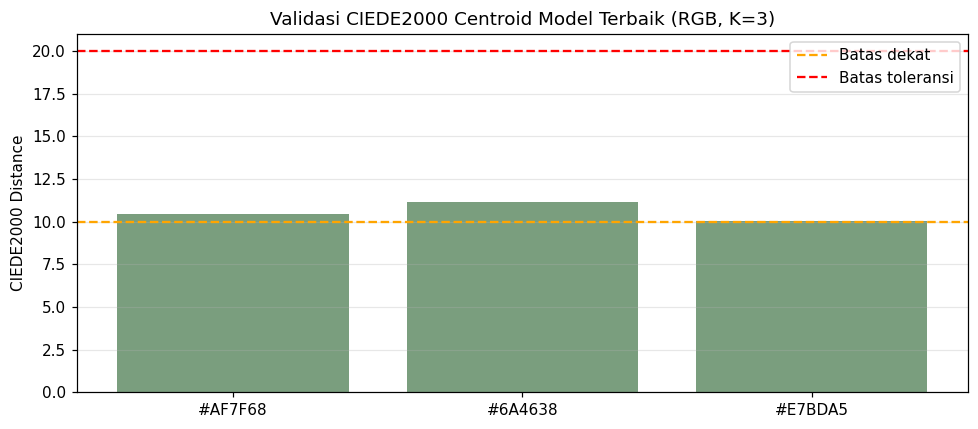

,Color Space,K,Avg CIEDE2000,Min CIEDE2000,Max CIEDE2000
7,LAB,5,9.464000,6.028,12.098
2,RGB,7,9.494714,5.679,12.374
1,RGB,5,9.511400,6.205,12.494
8,LAB,7,9.606571,3.978,12.053
0,RGB,3,10.530000,10.020,11.135
6,LAB,3,10.558333,9.494,11.563
5,HSV,7,12.636143,7.407,22.702
4,HSV,5,13.111200,9.083,22.702
3,HSV,3,15.121667,9.503,22.702


In [13]:
SKIN_REFERENCE_COLORS = {
    "Very Light (ITA>55)": (255, 224, 189),
    "Light (ITA 41-55)": (241, 194, 125),
    "Intermediate (ITA 28-41)": (210, 160, 90),
    "Tan (ITA 10-28)": (180, 120, 60),
    "Brown (ITA -30 to 10)": (130, 80, 35),
    "Dark (ITA<-30)": (70, 35, 15),
}


def rgb_to_lab_colormath(rgb):
    srgb = sRGBColor(rgb[0] / 255.0, rgb[1] / 255.0, rgb[2] / 255.0)
    return convert_color(srgb, LabColor)


def compute_ciede2000(rgb1, rgb2):
    return float(delta_e_cie2000(rgb_to_lab_colormath(rgb1), rgb_to_lab_colormath(rgb2)))


def interpret_ciede2000(distance):
    if distance < 2:
        return "Sangat dekat - tidak terlihat berbeda"
    if distance <= 10:
        return "Dekat - merepresentasikan warna kulit"
    if distance <= 20:
        return "Sedang - masih dalam toleransi"
    return "JAUH - kemungkinan noise/background"


def validate_centroids_ciede2000(centroids_rgb, color_space_name=""):
    rows = []
    for idx, centroid in enumerate(centroids_rgb, start=1):
        rgb = tuple(int(x) for x in centroid)
        distances = {name: compute_ciede2000(rgb, ref_rgb) for name, ref_rgb in SKIN_REFERENCE_COLORS.items()}
        nearest_ref = min(distances, key=distances.get)
        min_distance = distances[nearest_ref]
        skintone, ita_value, _, _ = classify_skintone_ita(rgb)
        undertone = classify_undertone_lab(rgb)
        rows.append({
            "Color Space": color_space_name,
            "Cluster": idx,
            "Centroid Hex": "#{:02X}{:02X}{:02X}".format(*rgb),
            "ITA (deg)": round(ita_value, 2),
            "Skintone (ITA)": skintone,
            "Undertone": undertone,
            "Nearest Reference": nearest_ref,
            "CIEDE2000 Distance": round(min_distance, 3),
            "Interpretasi": interpret_ciede2000(min_distance),
        })
    return pd.DataFrame(rows)


df_ciede_best = validate_centroids_ciede2000(best_centroids_rgb, best_cs)
display(df_ciede_best)

plt.figure(figsize=(9, 4))
plt.bar(df_ciede_best["Centroid Hex"], df_ciede_best["CIEDE2000 Distance"], color="#7A9E7E")
plt.axhline(10, color="orange", linestyle="--", label="Batas dekat")
plt.axhline(20, color="red", linestyle="--", label="Batas toleransi")
plt.title(f"Validasi CIEDE2000 Centroid Model Terbaik ({best_cs}, K={best_k})")
plt.ylabel("CIEDE2000 Distance")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


validation_rows = []
for cs, results in BEST_RESULTS_MAP.items():
    for k, res in results.items():
        centroids_rgb = centroids_rgb_from_space(res["centroids"], cs)
        df_val = validate_centroids_ciede2000(centroids_rgb, cs)
        validation_rows.append({
            "Color Space": cs,
            "K": k,
            "Avg CIEDE2000": df_val["CIEDE2000 Distance"].mean(),
            "Min CIEDE2000": df_val["CIEDE2000 Distance"].min(),
            "Max CIEDE2000": df_val["CIEDE2000 Distance"].max(),
        })

df_ciede_summary = pd.DataFrame(validation_rows).sort_values("Avg CIEDE2000")
display(df_ciede_summary)


## 13. Visualisasi Dashboard Komprehensif

Dashboard menggabungkan ranking composite score, elbow curve, metrik clustering, validasi CIEDE2000, dan palet rekomendasi per cluster dengan label ITA.


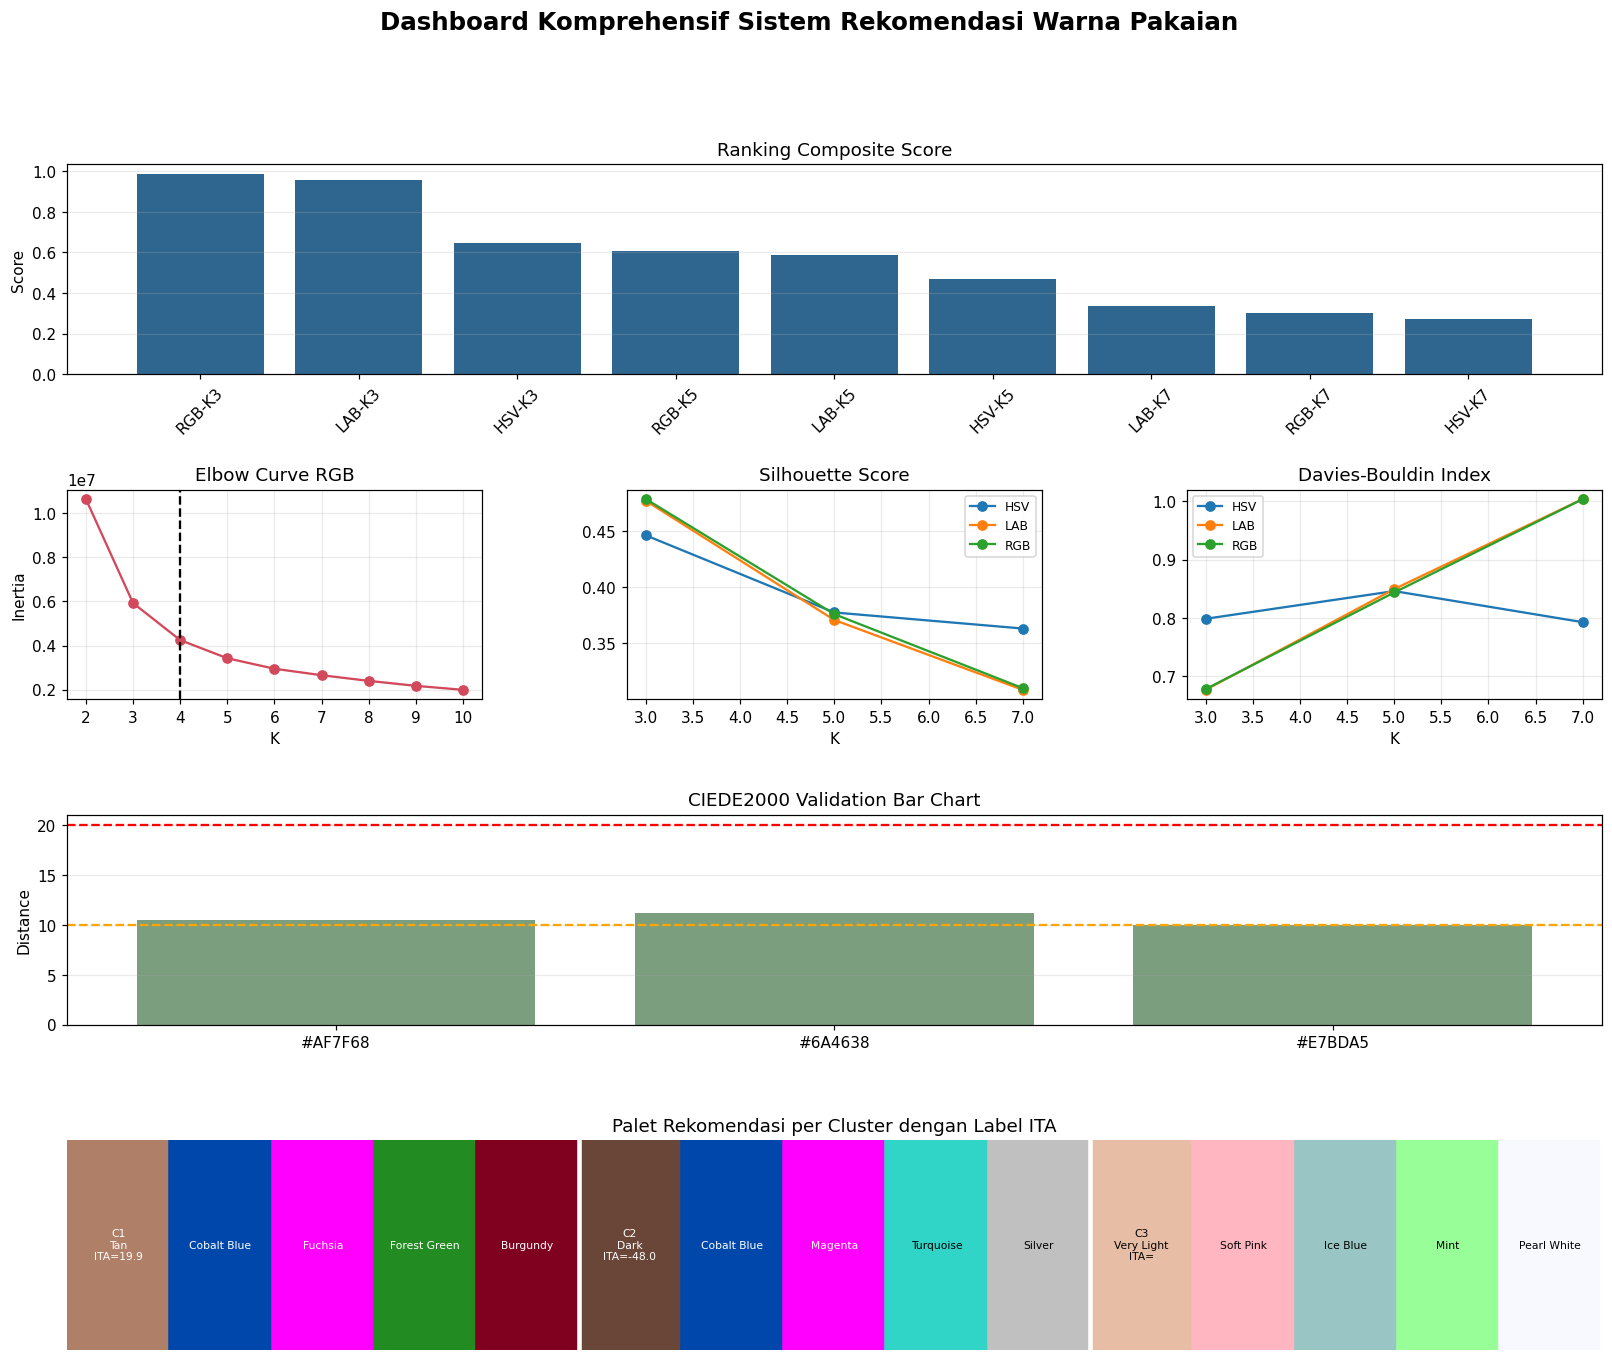

In [14]:
def plot_summary_dashboard():
    fig = plt.figure(figsize=(18, 14))
    gs = fig.add_gridspec(4, 3, hspace=0.55, wspace=0.35)
    fig.suptitle("Dashboard Komprehensif Sistem Rekomendasi Warna Pakaian", fontsize=16, fontweight="bold")

    ax1 = fig.add_subplot(gs[0, :])
    labels = [f"{r['Color Space']}-K{int(r['K'])}" for _, r in df_ranked.iterrows()]
    ax1.bar(labels, df_ranked["composite"], color="#2F6690")
    ax1.set_title("Ranking Composite Score")
    ax1.set_ylabel("Score")
    ax1.tick_params(axis="x", rotation=45)
    ax1.grid(axis="y", alpha=0.25)

    ax2 = fig.add_subplot(gs[1, 0])
    ax2.plot(elbow_rgb["K"], elbow_rgb["Inertia"], "o-", color="#D1495B")
    ax2.axvline(best_k_rgb_elbow, color="black", linestyle="--")
    ax2.set_title("Elbow Curve RGB")
    ax2.set_xlabel("K")
    ax2.set_ylabel("Inertia")
    ax2.grid(alpha=0.25)

    ax3 = fig.add_subplot(gs[1, 1])
    for cs, grp in df_eval.groupby("Color Space"):
        ax3.plot(grp["K"], grp["silhouette"], "o-", label=cs)
    ax3.set_title("Silhouette Score")
    ax3.set_xlabel("K")
    ax3.grid(alpha=0.25)
    ax3.legend(fontsize=8)

    ax4 = fig.add_subplot(gs[1, 2])
    for cs, grp in df_eval.groupby("Color Space"):
        ax4.plot(grp["K"], grp["davies_bouldin"], "o-", label=cs)
    ax4.set_title("Davies-Bouldin Index")
    ax4.set_xlabel("K")
    ax4.grid(alpha=0.25)
    ax4.legend(fontsize=8)

    ax5 = fig.add_subplot(gs[2, :])
    ax5.bar(df_ciede_best["Centroid Hex"], df_ciede_best["CIEDE2000 Distance"], color="#7A9E7E")
    ax5.axhline(10, color="orange", linestyle="--")
    ax5.axhline(20, color="red", linestyle="--")
    ax5.set_title("CIEDE2000 Validation Bar Chart")
    ax5.set_ylabel("Distance")
    ax5.grid(axis="y", alpha=0.25)

    ax6 = fig.add_subplot(gs[3, :])
    x = 0
    for i, centroid_rgb in enumerate(best_centroids_rgb, start=1):
        rec = get_clothing_recommendations(centroid_rgb)
        colors = [rec["skin_rgb"]] + [item["rgb"] for item in rec["recommended"]]
        labels = [f"C{i}\n{rec['skintone']}\nITA={rec['ita_value']:.1f}"] + [item["name"] for item in rec["recommended"]]
        for color_rgb, label in zip(colors, labels):
            ax6.add_patch(plt.Rectangle((x, 0), 1, 1, color=np.array(color_rgb) / 255.0))
            lum = 0.2126 * color_rgb[0] + 0.7152 * color_rgb[1] + 0.0722 * color_rgb[2]
            ax6.text(x + 0.5, 0.5, label[:18], ha="center", va="center", fontsize=7, color="black" if lum > 150 else "white")
            x += 1
        ax6.axvline(x, color="white", linewidth=3)
    ax6.set_xlim(0, x)
    ax6.set_ylim(0, 1)
    ax6.set_title("Palet Rekomendasi per Cluster dengan Label ITA")
    ax6.axis("off")

    plt.show()


plot_summary_dashboard()


## 14. Testing dengan Gambar User

Pipeline testing menggunakan konfigurasi model terbaik yang sudah dipilih: `best_cs` sebagai color space dan `best_k` sebagai jumlah cluster. Alur testing:

1. Load gambar user dari path atau array
2. Resize ke `TARGET_SIZE`
3. Preprocessing dengan CLAHE + Gaussian Blur
4. Deteksi wajah Haar Cascade dengan fallback bila wajah tidak terdeteksi
5. Segmentasi kulit voting 3 color space
6. Ekstraksi pixel kulit pada `best_cs`
7. K-Means dengan `best_k`
8. Klasifikasi ITA dan undertone untuk setiap centroid
9. Rekomendasi warna pakaian
10. Validasi CIEDE2000 centroid dominan terhadap referensi kulit standar

Format gambar yang disarankan: JPG atau PNG, wajah frontal, resolusi minimal 100x100 piksel.


In [15]:
from google.colab import files


def draw_face_bbox(img_rgb, bbox):
    canvas = img_rgb.copy()
    if bbox is None:
        cv2.putText(canvas, "Face not detected (fallback)", (12, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255, 0, 0), 2)
        return canvas
    x, y, w, h = bbox
    cv2.rectangle(canvas, (x, y), (x + w, y + h), (255, 0, 0), 2)
    return canvas


def nearest_skin_reference(rgb):
    distances = {name: compute_ciede2000(rgb, ref_rgb) for name, ref_rgb in SKIN_REFERENCE_COLORS.items()}
    nearest = min(distances, key=distances.get)
    return nearest, distances[nearest]


def predict_skin_and_recommend(img_input, color_space=None, k=None, verbose=True):
    cs = color_space or best_cs
    target_k = int(k or best_k)

    if isinstance(img_input, str):
        img_bgr = cv2.imread(img_input)
        if img_bgr is None:
            raise FileNotFoundError(f"Gambar tidak ditemukan: {img_input}")
    else:
        img_bgr = img_input.copy()

    img_bgr = cv2.resize(img_bgr, TARGET_SIZE, interpolation=cv2.INTER_AREA)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_proc = preprocess_image(img_bgr)

    face_crop, bbox = detect_and_crop_face(img_proc)
    face_detected = face_crop is not None
    if face_crop is None:
        print("PERINGATAN: Wajah tidak terdeteksi. Menggunakan gambar preprocessing langsung sebagai fallback.")
        analysis_img = img_proc
    else:
        analysis_img = cv2.resize(face_crop, TARGET_SIZE, interpolation=cv2.INTER_AREA)

    mask, _ = segment_skin_combined(analysis_img)
    pixels, _ = extract_skin_pixels(analysis_img, cs)
    if pixels is None or len(pixels) < 50:
        print("Error: pixel kulit kurang dari 50. Coba gambar wajah yang lebih jelas.")
        return []

    actual_k = min(target_k, len(pixels))
    _, labels, centroids, _ = run_kmeans(pixels, actual_k)
    centroids_rgb = centroids_rgb_from_space(centroids, cs)
    dominant_idx = int(np.bincount(labels).argmax())

    recommendations = []
    for centroid_rgb in centroids_rgb:
        rec = get_clothing_recommendations(centroid_rgb)
        recommendations.append(rec)

    dominant_rec = recommendations[dominant_idx]
    nearest_ref, nearest_dist = nearest_skin_reference(dominant_rec["skin_rgb"])

    if verbose:
        processed_rgb = cv2.cvtColor(analysis_img, cv2.COLOR_BGR2RGB)
        bbox_img = draw_face_bbox(cv2.cvtColor(img_proc, cv2.COLOR_BGR2RGB), bbox if face_detected else None)
        overlay = processed_rgb.copy()
        overlay[mask == 0] = [220, 220, 220]
        pct = (mask > 0).mean() * 100

        fig, axes = plt.subplots(1, 4, figsize=(16, 4))
        panels = [
            (img_rgb, "Input Gambar"),
            (bbox_img, "Deteksi Wajah (Haar Cascade)"),
            (processed_rgb, "Face Crop"),
            (overlay, f"Segmentasi Kulit\n({pct:.1f}% pixel kulit)"),
        ]
        for ax, (image, title) in zip(axes, panels):
            ax.imshow(image)
            ax.set_title(title)
            ax.axis("off")
        plt.tight_layout()
        plt.show()

        fig, ax = plt.subplots(figsize=(max(8, actual_k * 2), 2.8))
        for i, (rgb, rec) in enumerate(zip(centroids_rgb, recommendations)):
            ax.add_patch(plt.Rectangle((i, 0.35), 1, 0.65, color=rgb / 255.0))
            label = f"{rec['skin_hex']}\n{rec['skintone']}\nITA={rec['ita_value']:+.1f}\n{rec['undertone']}"
            if i == dominant_idx:
                label += "\n* DOMINAN"
            ax.text(i + 0.5, 0.28, label, ha="center", va="top", fontsize=8, color="red" if i == dominant_idx else "black")
        ax.set_xlim(0, actual_k)
        ax.set_ylim(0, 1.05)
        ax.set_title(f"Warna Kulit Terdeteksi - {cs}, K={actual_k}")
        ax.axis("off")
        plt.show()

        rec = dominant_rec
        colors = [rec["skin_rgb"]] + [item["rgb"] for item in rec["recommended"]]
        widths = [1.7] + [1] * len(rec["recommended"])
        fig, ax = plt.subplots(figsize=(12, 3.2))
        x = 0
        for idx, (rgb, width) in enumerate(zip(colors, widths)):
            ax.add_patch(plt.Rectangle((x, 0.38), width, 0.62, color=np.array(rgb) / 255.0))
            if idx == 0:
                label = f"KULIT\n{rec['skin_hex']}\n{rec['skintone']}\nITA={rec['ita_value']:.1f}"
            else:
                item = rec["recommended"][idx - 1]
                label = f"{item['name'][:10]}\n{item['hex']}"
            lum = 0.2126 * rgb[0] + 0.7152 * rgb[1] + 0.0722 * rgb[2]
            ax.text(x + width / 2, 0.69, label, ha="center", va="center", fontsize=8, color="black" if lum > 150 else "white")
            x += width
            if idx == 0:
                ax.axvline(x, color="white", linewidth=4)
        ax.text(0, 0.19, f"Undertone  : {rec['undertone']}", fontsize=9, va="top")
        ax.text(0, 0.10, f"Harmoni    : {rec['harmony']}", fontsize=9, va="top")
        ax.text(0, 0.01, "Rekomendasi: " + " | ".join([item["name"] for item in rec["recommended"]]), fontsize=9, va="top")
        ax.text(0, -0.08, f"Hindari    : {rec['avoid']}", fontsize=9, va="top")
        ax.text(0, -0.17, f"Alasan     : {rec['reason']}", fontsize=9, va="top")
        ax.set_xlim(0, x)
        ax.set_ylim(-0.25, 1.05)
        ax.set_title("Hasil Rekomendasi Cluster Dominan")
        ax.axis("off")
        plt.show()

        print("=" * 70)
        print("RINGKASAN HASIL")
        print("=" * 70)
        print(f"Face detected       : {face_detected}")
        print(f"Color space, K      : {cs}, K={actual_k}")
        print(f"Cluster dominan     : {dominant_idx + 1}")
        print(f"Skin RGB / Hex      : {rec['skin_rgb']} / {rec['skin_hex']}")
        print(f"Skintone ITA        : {rec['skintone']} (ITA={rec['ita_value']:.2f})")
        print(f"Undertone           : {rec['undertone']}")
        print(f"Nearest reference   : {nearest_ref}")
        print(f"CIEDE2000 distance  : {nearest_dist:.3f} - {interpret_ciede2000(nearest_dist)}")
        print(f"Rekomendasi warna   : {', '.join([item['name'] for item in rec['recommended']])}")
        print(f"Hindari             : {rec['avoid']}")
        print(f"Alasan              : {rec['reason']}")

    return recommendations


Saving images (1).jpg to images (1).jpg

Memproses: images (1).jpg


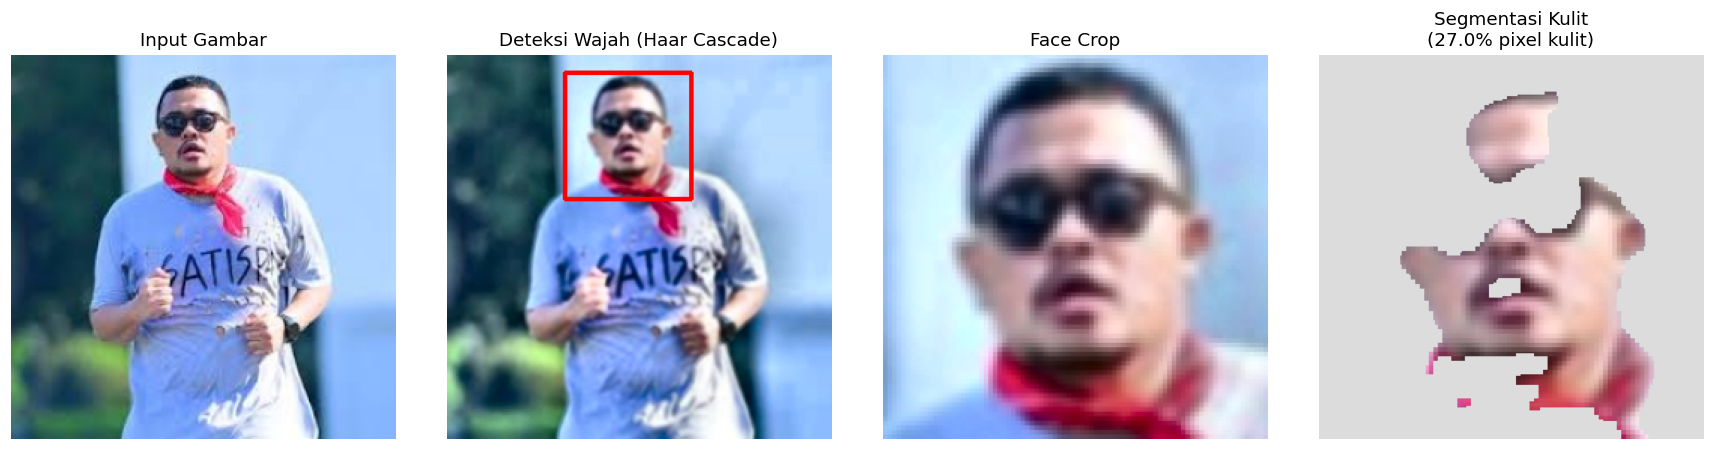

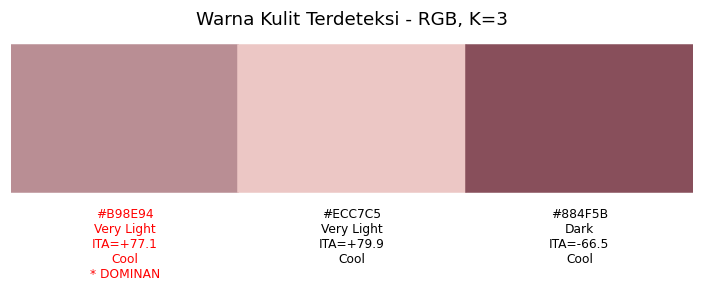

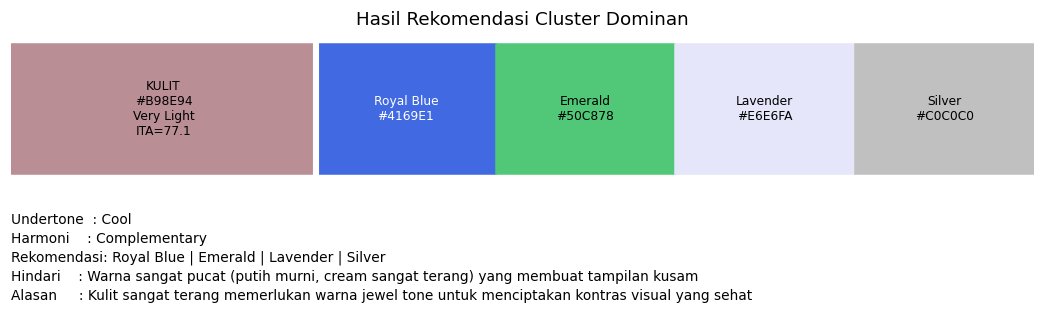

RINGKASAN HASIL
Face detected       : True
Color space, K      : RGB, K=3
Cluster dominan     : 1
Skin RGB / Hex      : (185, 142, 148) / #B98E94
Skintone ITA        : Very Light (ITA=77.14)
Undertone           : Cool
Nearest reference   : Tan (ITA 10-28)
CIEDE2000 distance  : 24.066 - JAUH - kemungkinan noise/background
Rekomendasi warna   : Royal Blue, Emerald, Lavender, Silver
Hindari             : Warna sangat pucat (putih murni, cream sangat terang) yang membuat tampilan kusam
Alasan              : Kulit sangat terang memerlukan warna jewel tone untuk menciptakan kontras visual yang sehat


In [16]:
uploaded = files.upload()

for filename in uploaded.keys():
    print(f"\nMemproses: {filename}")
    predict_skin_and_recommend(filename, color_space=best_cs, k=best_k, verbose=True)


### Cara Membaca Hasil Testing

| Komponen Output | Makna |
|---|---|
| Deteksi wajah | Menunjukkan apakah Haar Cascade berhasil menemukan wajah |
| Segmentasi kulit | Area berwarna asli adalah pixel kulit; area abu-abu diabaikan |
| Cluster dominan | Warna kulit yang paling banyak muncul pada hasil K-Means |
| ITA | Dasar kategori skintone dari CIELAB |
| Undertone | Warm, Cool, atau Neutral dari a* dan b* |
| CIEDE2000 | Jarak centroid dominan ke referensi warna kulit standar |
| Rekomendasi | Warna pakaian yang disarankan untuk cluster dominan |
| Hindari | Warna yang berisiko mengurangi kontras atau membuat tampilan kusam |


## 15. Kesimpulan

Cell terakhir mencetak kesimpulan penelitian berdasarkan model terbaik, nilai K, metrik clustering, validasi CIEDE2000, dan pipeline lengkap.


In [17]:
print("=" * 72)
print("KESIMPULAN PENELITIAN")
print("=" * 72)

best_row = df_ranked.iloc[0]
print(f"1. Color space terbaik: {best_cs}")
print(f"   Silhouette Score        : {best_row['silhouette']:.4f}")
print(f"   Davies-Bouldin Index    : {best_row['davies_bouldin']:.4f}")
print(f"   Calinski-Harabasz Index : {best_row['calinski_harabasz']:.2f}")
print(f"   Stability Score         : {best_row['Stability Score']:.4f}")
print(f"   Composite Score         : {best_row['composite']:.4f}")

print(f"\n2. K terbaik: {best_k}")
print(f"   Elbow Method RGB merekomendasikan K={best_k_rgb_elbow}.")
print("   Pemilihan akhir menggunakan composite score agar Silhouette, DBI, CHI, dan stabilitas dipertimbangkan bersama.")

print("\n3. Catatan evaluasi clustering:")
print("   Silhouette, DBI, dan CHI hanya mengukur struktur cluster.")
print("   Metrik tersebut belum membuktikan bahwa centroid adalah warna kulit yang benar secara visual.")

print("\n4. Validasi CIEDE2000:")
avg_ciede = df_ciede_best["CIEDE2000 Distance"].mean()
print(f"   Rata-rata jarak CIEDE2000 model terbaik: {avg_ciede:.3f}")
print("   Validasi ini membandingkan centroid dengan referensi warna kulit standar.")
display(df_ciede_best)

print("\n5. Pipeline lengkap:")
print("   Load dataset -> Preprocessing CLAHE -> Haar Cascade -> Segmentasi kulit voting RGB/HSV/YCrCb")
print("   -> Ekstraksi pixel kulit -> K-Means -> Evaluasi clustering -> Pemilihan model")
print("   -> Klasifikasi ITA CIELAB -> Rekomendasi warna -> Validasi CIEDE2000 -> Testing gambar user")

print("\nNotebook siap digunakan untuk eksperimen nyata dengan mengganti DATASET_PATH ke dataset Kaggle.")


KESIMPULAN PENELITIAN
1. Color space terbaik: RGB
   Silhouette Score        : 0.4784
   Davies-Bouldin Index    : 0.6783
   Calinski-Harabasz Index : 6951.57
   Stability Score         : 0.1533
   Composite Score         : 0.9856

2. K terbaik: 3
   Elbow Method RGB merekomendasikan K=4.
   Pemilihan akhir menggunakan composite score agar Silhouette, DBI, CHI, dan stabilitas dipertimbangkan bersama.

3. Catatan evaluasi clustering:
   Silhouette, DBI, dan CHI hanya mengukur struktur cluster.
   Metrik tersebut belum membuktikan bahwa centroid adalah warna kulit yang benar secara visual.

4. Validasi CIEDE2000:
   Rata-rata jarak CIEDE2000 model terbaik: 10.530
   Validasi ini membandingkan centroid dengan referensi warna kulit standar.


,Color Space,Cluster,Centroid Hex,ITA (deg),Skintone (ITA),Undertone,Nearest Reference,CIEDE2000 Distance,Interpretasi
0,RGB,1,#AF7F68,19.94,Tan,Cool,Tan (ITA 10-28),10.435,Sedang - masih dalam toleransi
1,RGB,2,#6A4638,-48.01,Dark,Cool,Brown (ITA -30 to 10),11.135,Sedang - masih dalam toleransi
2,RGB,3,#E7BDA5,58.70,Very Light,Neutral,Very Light (ITA>55),10.020,Sedang - masih dalam toleransi



5. Pipeline lengkap:
   Load dataset -> Preprocessing CLAHE -> Haar Cascade -> Segmentasi kulit voting RGB/HSV/YCrCb
   -> Ekstraksi pixel kulit -> K-Means -> Evaluasi clustering -> Pemilihan model
   -> Klasifikasi ITA CIELAB -> Rekomendasi warna -> Validasi CIEDE2000 -> Testing gambar user

Notebook siap digunakan untuk eksperimen nyata dengan mengganti DATASET_PATH ke dataset Kaggle.
